In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
#====================================================================================================#
# Import Libraries
#====================================================================================================#
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras import layers
warnings.filterwarnings('ignore')

In [4]:
#====================================================================================================#
# Load Dataset
#====================================================================================================#
IMAGE_SIZE = (224,224)
BATCH_SIZE = 64
SEED = 123
AUTOTUNE = tf.data.AUTOTUNE

training_dataset = '/kaggle/input/datasets/haroon669/cats-vs-dogs-dataset-10k-cat-10k-dog-images/dogs_vs_cats/train'
testing_dataset = '/kaggle/input/datasets/haroon669/cats-vs-dogs-dataset-10k-cat-10k-dog-images/dogs_vs_cats/test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    training_dataset,
    validation_split = 0.2,
    subset = 'training',
    seed = SEED,
    shuffle = True,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    training_dataset,
    validation_split = 0.2,
    subset = 'validation',
    seed = SEED,
    shuffle = True,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    testing_dataset,
    shuffle = False,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE
)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size = AUTOTUNE)

print(f"Training Dataset Batches: {len(train_ds)}")
print(f"Validation Dataset Batches: {len(val_ds)}")
print(f"Testing Dataset Batches: {len(test_ds)}")
print("✅ Dataset Loading and Spliting Complete!")

Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Found 5000 files belonging to 2 classes.
Training Dataset Batches: 250
Validation Dataset Batches: 63
Testing Dataset Batches: 79
✅ Dataset Loading and Spliting Complete!


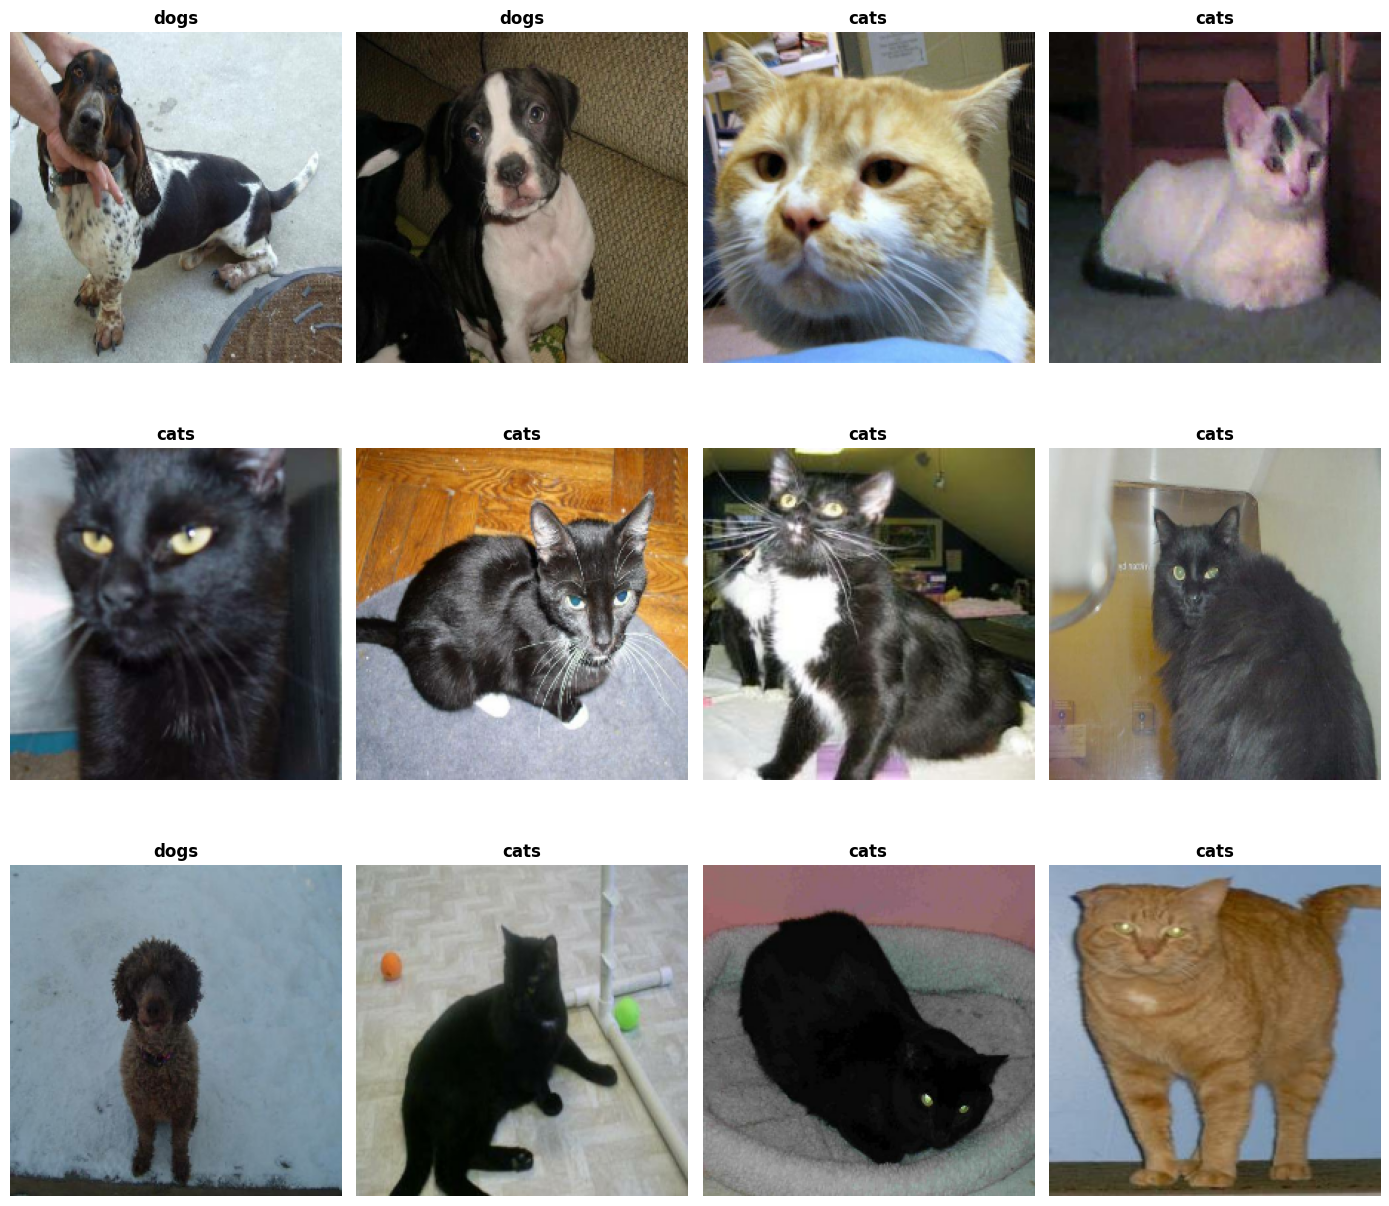

In [5]:
#====================================================================================================#
# Preview The Training Dataset Images
#====================================================================================================#
for images,labels in train_ds.take(1):
    plt.figure(figsize = (14,13))
    for img in range(12):
        plt.subplot(3,4,img + 1)
        plt.title(class_names[labels[img]],fontsize = 12,fontweight = 'bold')
        plt.imshow(images[img].numpy().astype('uint8'))
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

In [6]:
#====================================================================================================#
# Model Building
#====================================================================================================#
base_model = ResNet50(
    input_shape = (224,224,3),
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable = False

model = Sequential()

In [7]:
model.add(layers.Input(shape = (224,224,3)))

model.add(layers.RandomFlip('horizontal'))
model.add(layers.RandomRotation(0.2))
model.add(layers.RandomZoom(0.3))
model.add(layers.RandomContrast(0.3))
model.add(layers.RandomBrightness(0.2))

model.add(layers.Lambda(tf.keras.applications.resnet50.preprocess_input))
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(256,activation = 'relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(1,activation = 'sigmoid'))

model.summary()

# Compile The Model
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

earlystopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True,
    verbose = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    patience = 3,
    factor = 0.2,
    min_lr = 1e-6,
    verbose = 1
)
# Fit The Model
print("Model Training Start...")
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks = [earlystopping,reduce_lr]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Model Training Start...
Epoch 1/10


I0000 00:00:1782477358.377335    4672 cuda_dnn.cc:529] Loaded cuDNN version 91002


250/250 ━━━━━━━━━━━━━━━━━━━━ 95s 329ms/step - accuracy: 0.9285 - loss: 0.1735 - val_accuracy: 0.9862 - val_loss: 0.0397 - learning_rate: 1.0000e-04
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 312ms/step - accuracy: 0.9613 - loss: 0.0989 - val_accuracy: 0.9885 - val_loss: 0.0344 - learning_rate: 1.0000e-04
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 312ms/step - accuracy: 0.9629 - loss: 0.0914 - val_accuracy: 0.9880 - val_loss: 0.0336 - learning_rate: 1.0000e-04
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 311ms/step - accuracy: 0.9660 - loss: 0.0867 - val_accuracy: 0.9862 - val_loss: 0.0367 - learning_rate: 1.0000e-04
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 311ms/step - accuracy: 0.9683 - loss: 0.0836 - val_accuracy: 0.9880 - val_loss: 0.0328 - learning_rate: 1.0000e-04
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 311ms/step - accuracy: 0.9706 - loss: 0.0766 - val_accuracy: 0.9880 - val_loss: 0.0313 - learning_rate: 1.0000e-04
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 311ms/step - 

In [8]:
#====================================================================================================#
# Model Evaluation on Test Dataset
#====================================================================================================#
test_result = model.evaluate(test_ds)
print(f"Testing Loss: {test_result[0]:.2f}")
print(f"Testing Accuracy: {test_result[1] * 100:.2f}%")

79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.9898 - loss: 0.0275
Testing Loss: 0.03
Testing Accuracy: 98.98%


In [9]:
#====================================================================================================#
# Model Evaluation on Train Dataset
#====================================================================================================#
train_result = model.evaluate(train_ds)
print(f"Training Loss: {train_result[0]:.2f}")
print(f"Training Accuracy: {train_result[1] * 100:.2f}%")

250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 243ms/step - accuracy: 0.9931 - loss: 0.0200
Training Loss: 0.02
Training Accuracy: 99.31%


In [10]:
#====================================================================================================#
# Model Evaluation on validation Dataset
#====================================================================================================#
val_result = model.evaluate(val_ds)
print(f"Validation Loss: {val_result[0]:.2f}")
print(f"Validation Accuracy: {val_result[1] * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 241ms/step - accuracy: 0.9885 - loss: 0.0299
Validation Loss: 0.03
Validation Accuracy: 98.85%


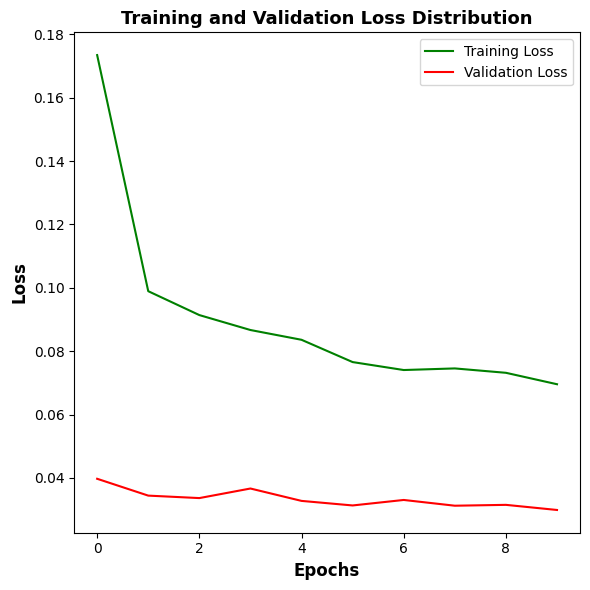

In [11]:
#====================================================================================================#
# Training and Validation Loss Visualization
#====================================================================================================#
plt.figure(figsize = (6,6))
plt.title("Training and Validation Loss Distribution",fontsize = 13,fontweight = 'bold')
plt.plot(history.history['loss'],label = 'Training Loss',color = 'green')
plt.plot(history.history['val_loss'],label = 'Validation Loss',color = 'red')
plt.xlabel('Epochs',fontsize = 12,fontweight = 'bold')
plt.ylabel('Loss',fontsize = 12,fontweight = 'bold')
plt.legend()
plt.tight_layout()
plt.savefig('Training_and_Validation_Loss.png')
plt.show()

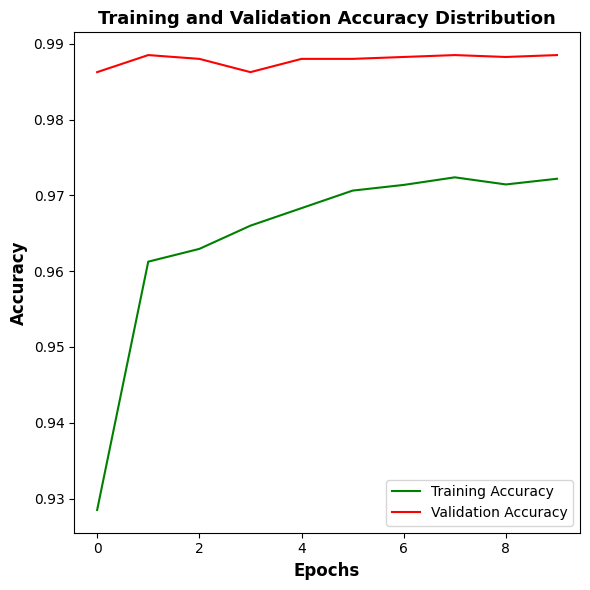

In [12]:
#====================================================================================================#
# Training and Validation Accuracy Visualization
#====================================================================================================#
plt.figure(figsize = (6,6))
plt.title("Training and Validation Accuracy Distribution",fontsize = 13,fontweight = 'bold')
plt.plot(history.history['accuracy'],label = 'Training Accuracy',color = 'green')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy',color = 'red')
plt.xlabel('Epochs',fontsize = 12,fontweight = 'bold')
plt.ylabel('Accuracy',fontsize = 12,fontweight = 'bold')
plt.legend()
plt.tight_layout()
plt.savefig('Training_and_Validation_Accuracy.png')
plt.show()

In [13]:
#====================================================================================================#
# Model Evaluation
#====================================================================================================#
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_pred_proba = model.predict(test_ds)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print(f"Accuracy Score: {accuracy_score(y_true, y_pred):.4f}")
print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_true,y_pred)}")
auc_score = roc_auc_score(y_true, y_pred_proba.flatten())
print(f"ROC-AUC Score: {auc_score:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 262ms/step
Accuracy Score: 0.9898

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2500
           1       0.99      0.99      0.99      2500

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000


Confusion Matrix:
[[2467   33]
 [  18 2482]]
ROC-AUC Score: 0.9994


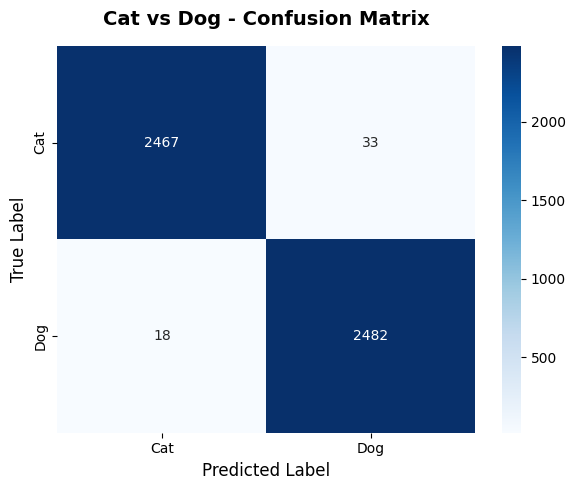

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Cat', 'Dog'], 
            yticklabels=['Cat', 'Dog'])
plt.title('Cat vs Dog - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step


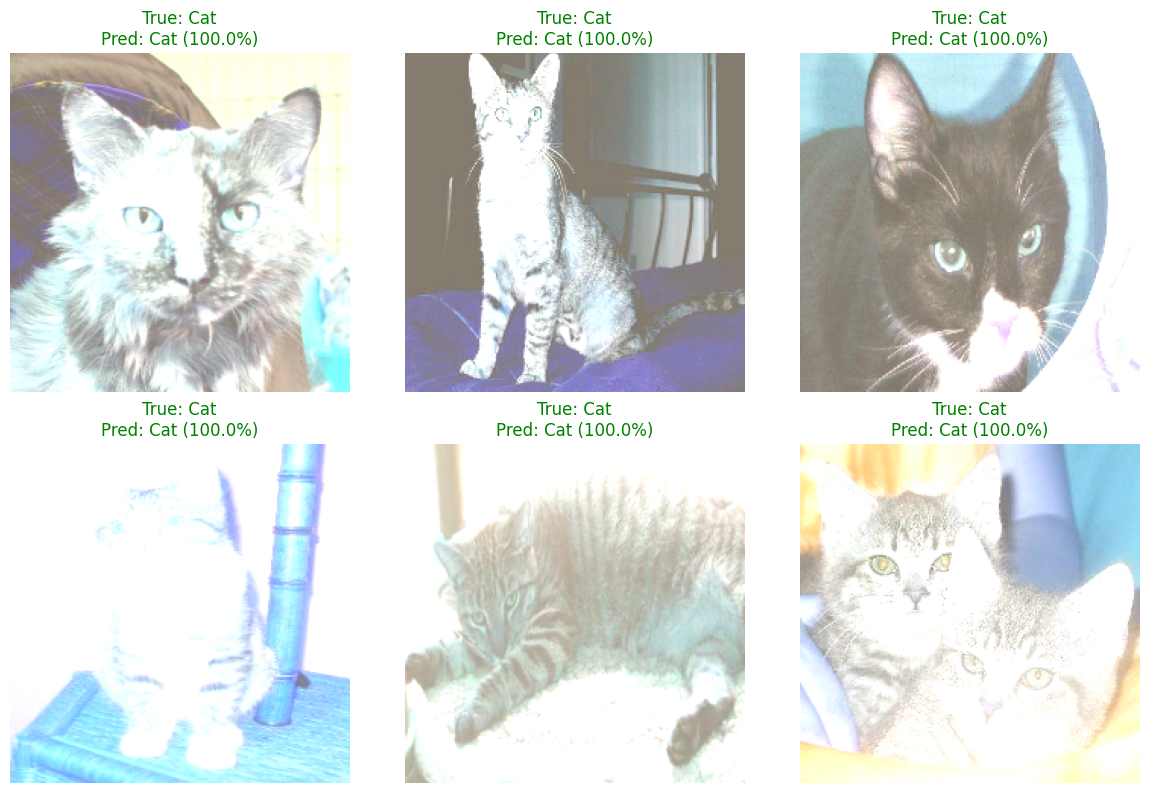

In [19]:
#===================================================================================================#
# Prediction On Test Dataset
#===================================================================================================#
y_pred_proba = model.predict(test_ds)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

for images, labels in test_ds.take(1):
    x_test_batch = images.numpy()
    y_true_batch = labels.numpy()
    break

def deprocess_resnet_image(img):
    x = img.copy()
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]
    return np.clip(x, 0, 255).astype('uint8')

class_names = {0: 'Cat', 1: 'Dog'}

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(deprocess_resnet_image(x_test_batch[i]))
    
    true_label = class_names[int(y_true_batch[i])]
    pred_label = class_names[y_pred[i]]
    
    raw_prob = float(y_pred_proba[i][0]) if len(y_pred_proba[i].shape) > 0 else float(y_pred_proba[i])
    prob = raw_prob if y_pred[i] == 1 else 1 - raw_prob
    
    title_color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label} ({prob*100:.1f}%)", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.savefig('Model_Prediction_Images')
plt.show()


In [20]:
#===================================================================================================#
# Save The Model
#===================================================================================================#
model.save('CAT_Vs_DOG_Image_Classification_Model.keras')
print("✅ Model Saved Complete!")

✅ Model Saved Complete!
